In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from SynOmics.metrics.narrow_utility.GSEA import PCSAnalyzer

*******0*******
Skipping TVAE: [Errno 2] No such file or directory: 'NivoBenefit_Jiter/Seed_0/GSEA_tvae_0.csv'


/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/SynOmics/metrics/narrow_utility/GSEA.py:358: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


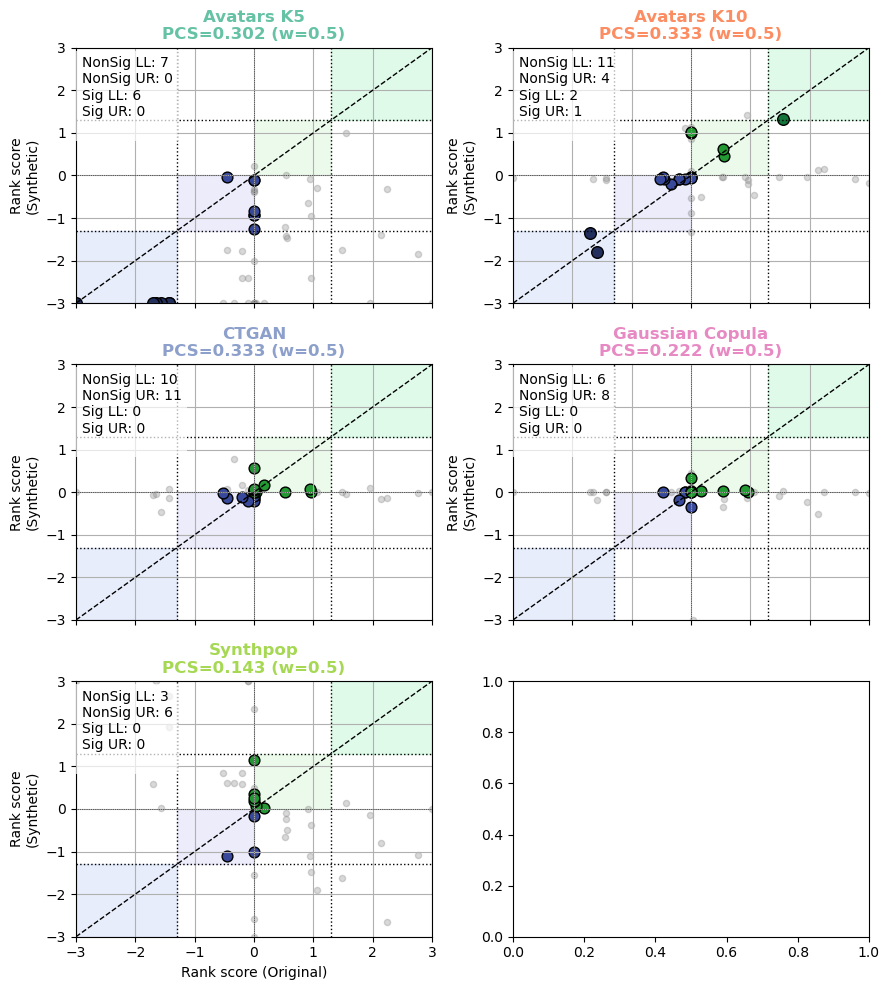

*******1*******
Skipping TVAE: [Errno 2] No such file or directory: 'NivoBenefit_Jiter/Seed_1/GSEA_tvae_1.csv'


/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/SynOmics/metrics/narrow_utility/GSEA.py:358: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


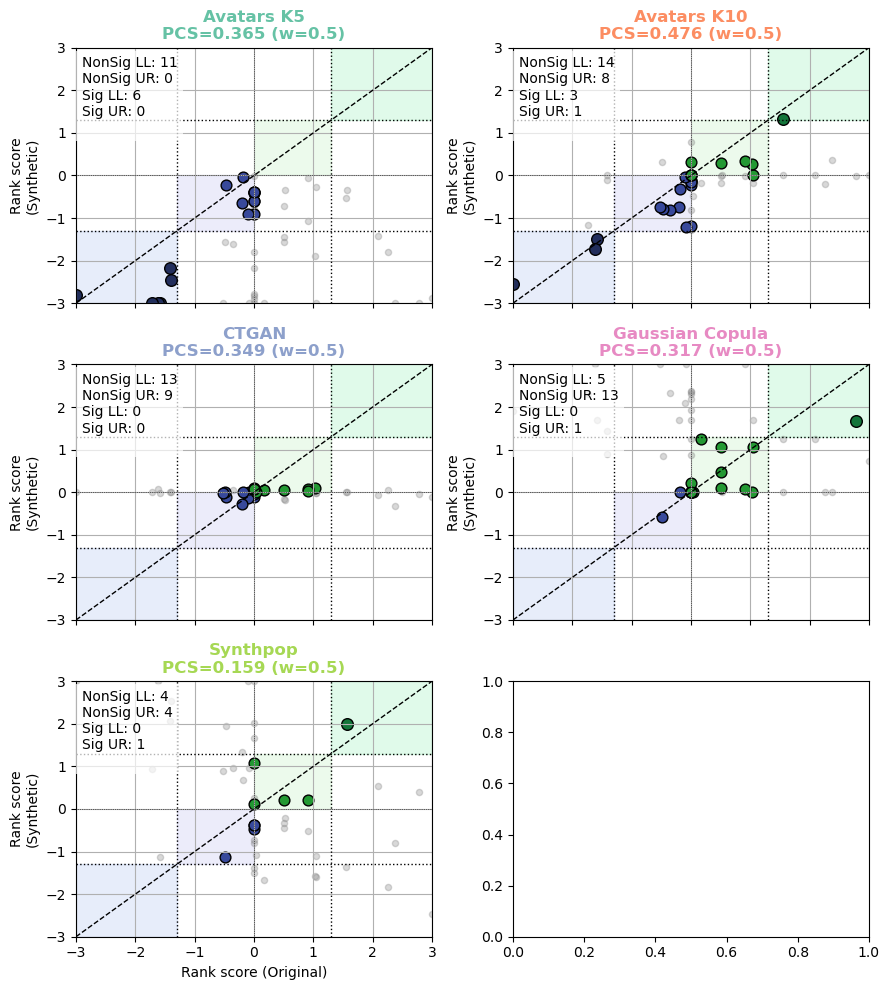

*******2*******
Skipping TVAE: [Errno 2] No such file or directory: 'NivoBenefit_Jiter/Seed_2/GSEA_tvae_2.csv'


/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/SynOmics/metrics/narrow_utility/GSEA.py:358: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


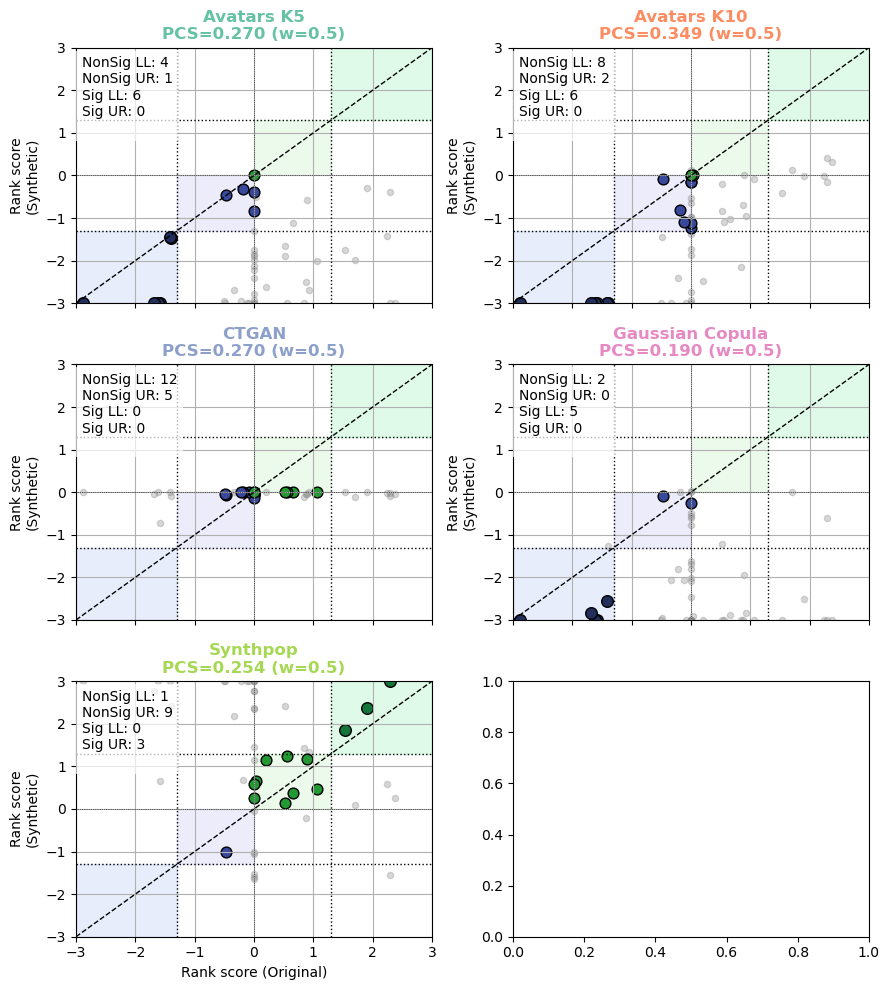

*******3*******
Skipping TVAE: [Errno 2] No such file or directory: 'NivoBenefit_Jiter/Seed_3/GSEA_tvae_3.csv'


/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/SynOmics/metrics/narrow_utility/GSEA.py:358: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


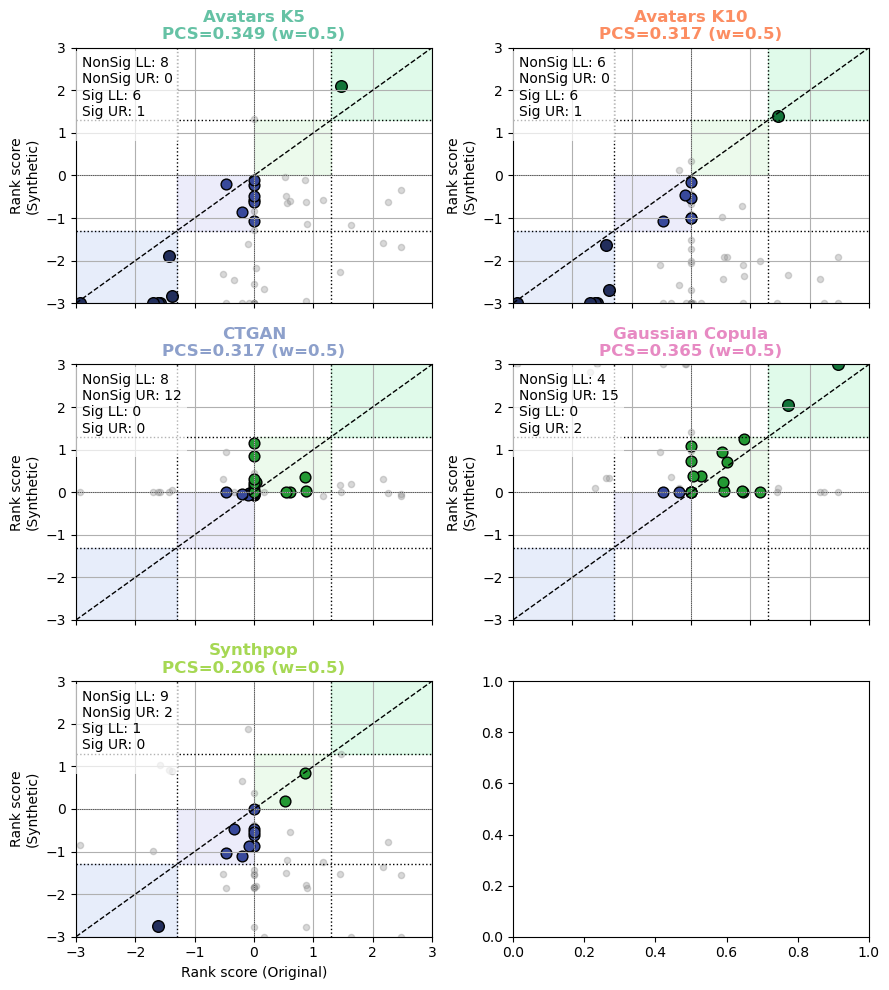

*******42*******
Skipping TVAE: [Errno 2] No such file or directory: 'NivoBenefit_Jiter/Seed_42/GSEA_tvae_42.csv'


/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/SynOmics/metrics/narrow_utility/GSEA.py:358: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


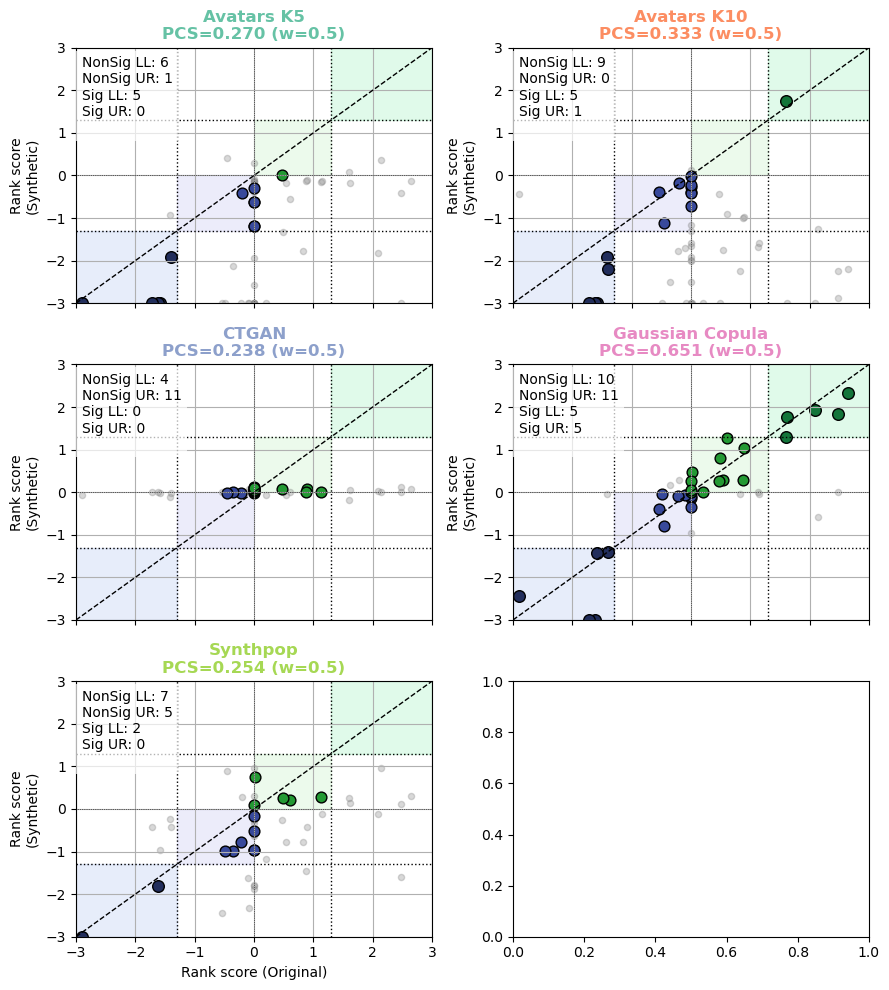

PCS scores across seeds:
Avatars K5: 0.31111111111111106 +/- 0.03965078094221205
Avatars K10: 0.36190476190476184 +/- 0.05801799010316528
CTGAN: 0.30158730158730157 +/- 0.041391761302873954
Gaussian Copula: 0.3492063492063492 +/- 0.1634227006505873
Synthpop: 0.20317460317460317 +/- 0.04644044075659617


In [7]:
seeds = [0, 1, 2, 3, 42]
pcs_scores_across_seeds = {}


for seed in seeds:
    print(f"*******{seed}*******")

    dataset_dict = {
        'Avatars K5': f'NivoBenefit_Jiter/Seed_{seed}/GSEA_avatarsk5_{seed}.csv',
        'Avatars K10': f'NivoBenefit_Jiter/Seed_{seed}/GSEA_avatarsk10_{seed}.csv',
        'CTGAN': f'NivoBenefit_Jiter/Seed_{seed}/GSEA_ctgan_{seed}.csv',
        'Gaussian Copula': f'NivoBenefit_Jiter/Seed_{seed}/GSEA_gaussiancopula_{seed}.csv',
        'Synthpop': f'NivoBenefit_Jiter/Seed_{seed}/GSEA_synthpop_{seed}.csv',
        'TVAE': f'NivoBenefit_Jiter/Seed_{seed}/GSEA_tvae_{seed}.csv',
    }
    ori_path = f'NivoBenefit_Jiter/Seed_{seed}/GSEA_Origin.csv'

    analyzer = PCSAnalyzer(
        term_col="Term",
        nes_col="NES",
        q_col="FDR q-val",
        seed=42,
        q_thr=0.05,
        w=0.5,
    )

    fig, pcs_dict = analyzer.plot_gsea_datasets(
        ori_path=ori_path,
        dataset_dict=dataset_dict,
        figsize=(9, 10),
    )

    fig.savefig(f"PCS/Seed_{seed}.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(f"PCS/Seed_{seed}.png", dpi=300, bbox_inches="tight")
    for tool, pcs in pcs_dict.items():
        if tool not in pcs_scores_across_seeds:
            pcs_scores_across_seeds[tool] = []
        pcs_scores_across_seeds[tool].append(pcs)

pcs_across_seed_df = pd.DataFrame(pcs_scores_across_seeds)
pcs_across_seed_df.to_csv("PCS/pcs_score.csv", index=False)

print("PCS scores across seeds:")
for tool, pcs_list in pcs_scores_across_seeds.items():
    print(f"{tool}: {np.mean(pcs_list)} +/- {np.std(pcs_list)}")

/tmp/ipykernel_391879/4134531461.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_391879/4134531461.py:16: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


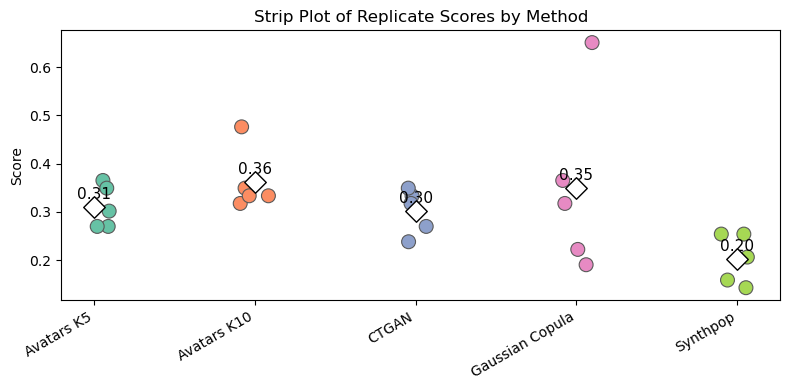

In [9]:
score_dict =pcs_scores_across_seeds

# Convert to long DataFrame
rows = []
for method, scores in score_dict.items():
    for score in scores:
        rows.append({'Method': method, 'Score': score})

df_long = pd.DataFrame(rows)

# Order for aesthetics (optional, or sorted by mean)
method_order = list(score_dict.keys())

plt.figure(figsize=(8, 4))

sns.stripplot(
    x='Method', 
    y='Score', 
    data=df_long, 
    order=method_order,
    size=10, 
    jitter=True, 
    palette='Set2', 
    edgecolor='gray', 
    linewidth=0.8,
)

# Show mean of each method as diamond marker
means = df_long.groupby("Method")["Score"].mean().reindex(method_order)
for i, mu in enumerate(means):
    plt.scatter(i, mu, marker='D', color='white', edgecolor='black', s=120, zorder=10, label=None)
    plt.text(i, mu + 0.01, f"{mu:.2f}", ha="center", va="bottom", fontsize=11, color="black")

plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=30, ha='right')
plt.title("Strip Plot of Replicate Scores by Method")
plt.tight_layout()
plt.show()

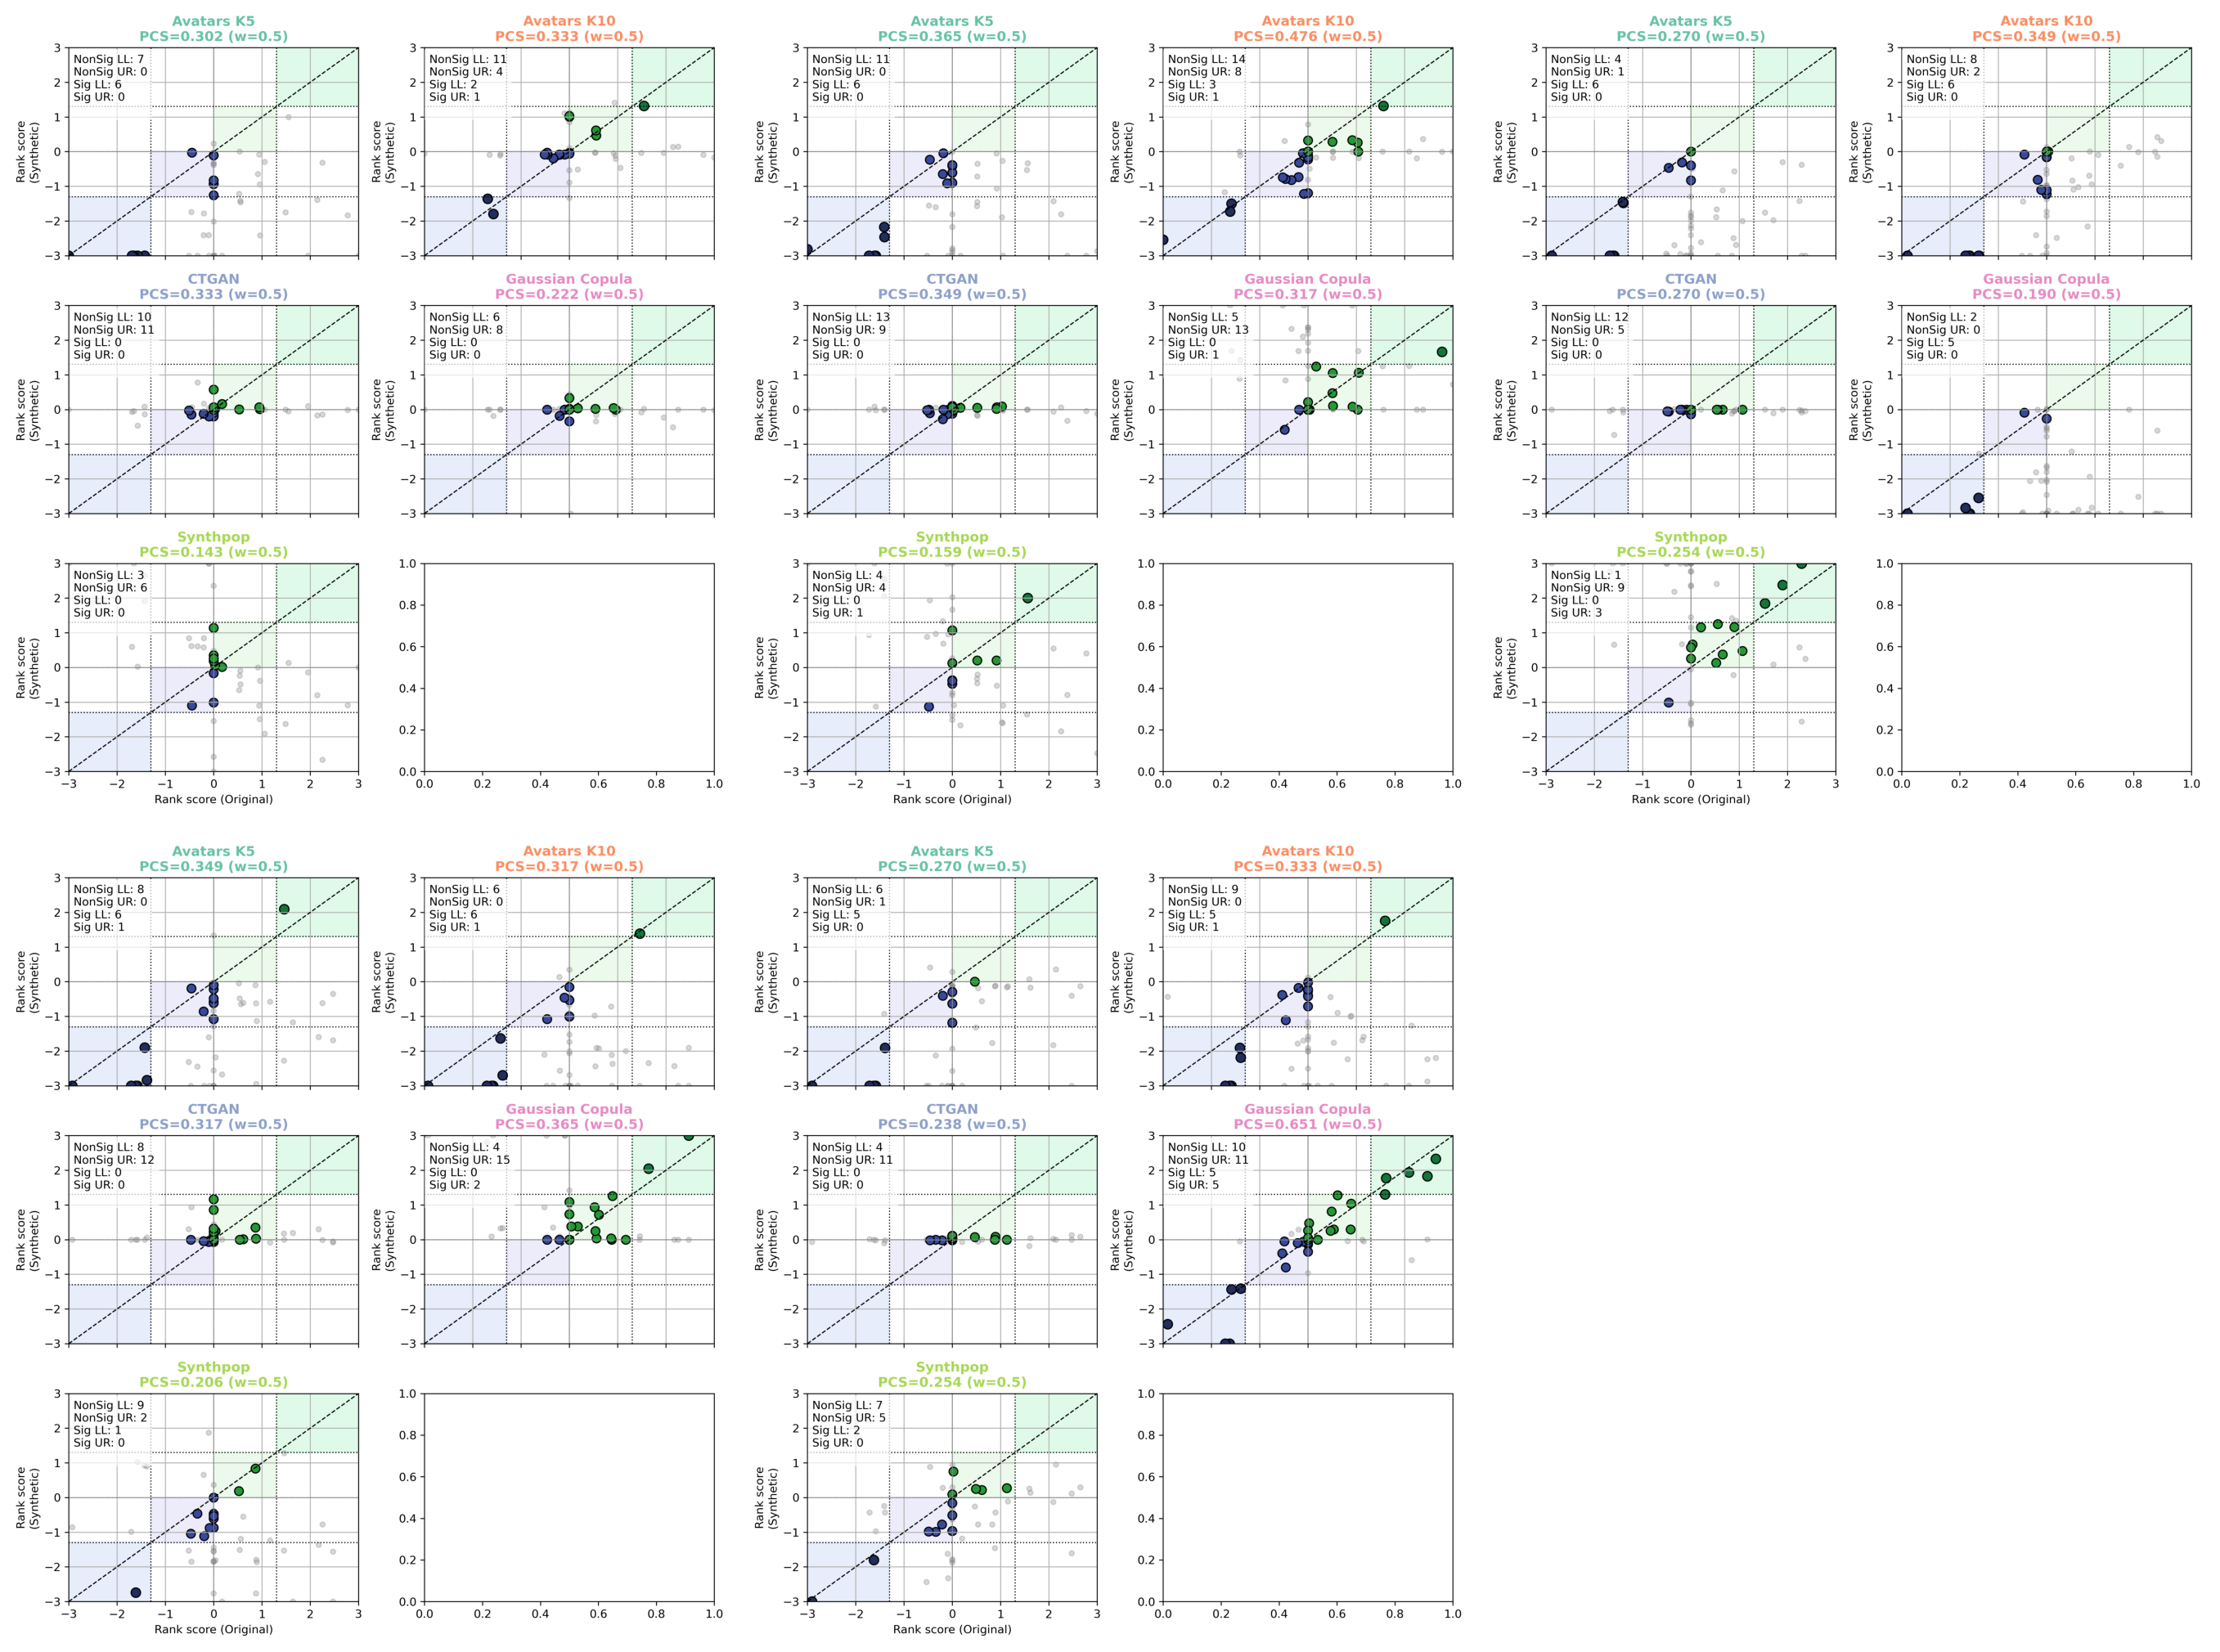

In [16]:
import matplotlib.image as mpimg
from matplotlib import gridspec

n_rows = 2
n_cols = 3



fig = plt.figure(figsize=(27, 20))

gs = gridspec.GridSpec(
    n_rows, n_cols,
    figure=fig,
    wspace=0.01, 
    hspace=0.03  
)

def show_img(ax, path):
    try:
        img = mpimg.imread(path)
        ax.imshow(img)
    except FileNotFoundError:
        ax.text(0.5, 0.5, "Image Not Found", ha='center', fontsize=15)
    ax.axis("off")

for i, seed in enumerate(seeds):
    
    row = i // n_cols  
    col = i % n_cols   
    
    path = f"PCS/Seed_{seed}.png"
    ax = fig.add_subplot(gs[row, col])
    show_img(ax, path)

if len(seeds) < n_rows * n_cols:
    for j in range(len(seeds), n_rows * n_cols):
        ax_empty = fig.add_subplot(gs[j // n_cols, j % n_cols])
        ax_empty.axis("off")

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

fig.savefig("PCS/Combined_3x2_images.png", dpi=300, bbox_inches="tight")
plt.show()